In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("C:/Users/morep/Downloads/StudentsPerformance_Prac2_100.csv")
df

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count
0,64,NaN,70.0,88.0,2020.0,3
1,68,94.0,62.0,79.0,2020.0,2
2,72,88.0,77.0,90.0,2018.0,3
3,77,80.0,63.0,99.0,2020.0,3
4,80,93.0,60.0,96.0,2020.0,3
...,...,...,...,...,...,...
95,61,84.0,69.0,68.0,NaN,1
96,72,75.0,86.0,NaN,2020.0,2
97,95,85.0,80.0,61.0,2021.0,1
98,69,88.0,55.0,99.0,NaN,3


In [5]:
df.head()

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count
0,64,NaN,70.0,88.0,2020.0,3
1,68,94.0,62.0,79.0,2020.0,2
2,72,88.0,77.0,90.0,2018.0,3
3,77,80.0,63.0,99.0,2020.0,3
4,80,93.0,60.0,96.0,2020.0,3


In [6]:
df.shape

(100, 6)

In [7]:
df.columns

Index(['Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score',
       'Club_Join_Date', 'Placement_Offer_Count'],
      dtype='object')

In [8]:
df.dtypes

Math_Score                 int64
Reading_Score            float64
Writing_Score            float64
Placement_Score          float64
Club_Join_Date           float64
Placement_Offer_Count      int64
dtype: object

In [9]:
df.isnull().sum()

Math_Score                0
Reading_Score             9
Writing_Score             7
Placement_Score           3
Club_Join_Date           22
Placement_Offer_Count     0
dtype: int64

In [10]:
series = pd.isnull(df["Math_Score"])
df[series]

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count


In [12]:
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].mean())
df['Reading_Score'] = df['Reading_Score'].fillna(df['Reading_Score'].median())
df['Writing_Score'] = df['Writing_Score'].fillna(df['Writing_Score'].median())
df['Placement_Score'] = df['Placement_Score'].fillna(df['Placement_Score'].mean())
df


,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count
0,64,85.0,70.0,88.000000,2020.0,3
1,68,94.0,62.0,79.000000,2020.0,2
2,72,88.0,77.0,90.000000,2018.0,3
3,77,80.0,63.0,99.000000,2020.0,3
4,80,93.0,60.0,96.000000,2020.0,3
...,...,...,...,...,...,...
95,61,84.0,69.0,68.000000,NaN,1
96,72,75.0,86.0,87.804124,2020.0,2
97,95,85.0,80.0,61.000000,2021.0,1
98,69,88.0,55.0,99.000000,NaN,3


In [19]:
df['Club_Join_Date'] = df['Club_Join_Date'].fillna(df['Club_Join_Date'].mode())

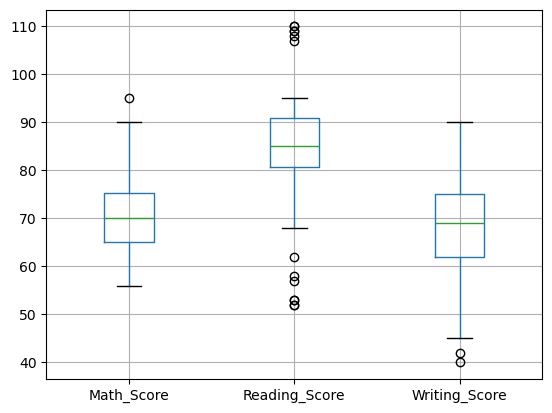

In [15]:
col = ['Math_Score', 'Reading_Score', 'Writing_Score']
df.boxplot(col)
plt.show()


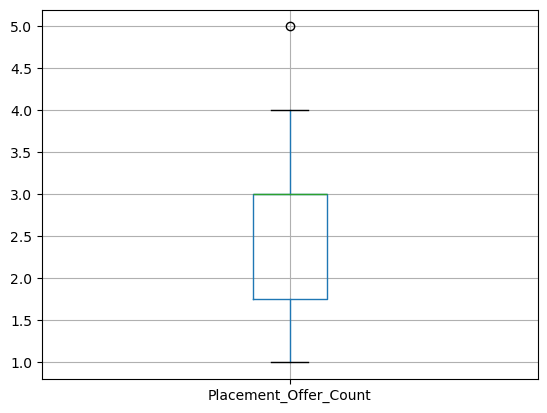

In [16]:
col = ['Placement_Offer_Count']
df.boxplot(col)
plt.show()

In [18]:
import numpy as np
from scipy import stats
z = np.abs(stats.zscore(df['Math_Score']))
print(z)


[0.89567475 0.31594999 0.26377476 0.98843071 1.42322428 0.84349952
 0.26377476 1.04060594 0.75074356 0.31594999 0.26377476 0.1710188
 1.04060594 0.98843071 0.84349952 1.33046832 1.47539951 0.40870595
 0.98843071 0.69856833 0.98843071 0.60581237 2.05512426 0.60581237
 1.04060594 1.18553713 0.84349952 1.18553713 1.27829309 0.26377476
 0.11884358 1.33046832 1.27829309 0.40870595 0.84349952 1.1333619
 0.02608761 0.26377476 1.42322428 0.75074356 0.84349952 1.42322428
 0.75074356 1.18553713 0.40870595 0.11884358 0.1710188  1.18553713
 0.40870595 1.27829309 0.02608761 1.42322428 0.26377476 0.11884358
 0.75074356 1.18553713 0.31594999 0.31594999 0.46088118 0.40870595
 0.69856833 1.33046832 1.47539951 0.02608761 0.69856833 1.1333619
 1.27829309 1.18553713 0.11884358 0.98843071 0.46088118 0.89567475
 0.46088118 0.02608761 1.04060594 0.60581237 1.42322428 1.04060594
 0.26377476 0.84349952 1.27829309 0.69856833 0.02608761 1.47539951
 0.75074356 1.33046832 0.02608761 0.40870595 1.18553713 2.8725361

In [20]:
np.where

<function where at 0x000002963A2545B0>

In [21]:
threshold = 3
np.where(z > threshold)

(array([97]),)

In [22]:
sorted_rscore = sorted(df['Reading_Score'])
q1 = np.percentile(sorted_rscore, 25)
q3 = np.percentile(sorted_rscore, 75)
IQR = q3-q1
lower = q1-(1.5 * IQR)
upper = q3 + (1.5 * IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: 65.375
Upper Bound: 106.375


In [24]:
outliers = []
for i in sorted_rscore:
    if i < lower or i > upper:
        outliers.append(i)
outliers

[52.0,
 52.0,
 53.0,
 53.0,
 57.0,
 58.0,
 62.0,
 107.0,
 108.0,
 109.0,
 109.0,
 110.0,
 110.0]

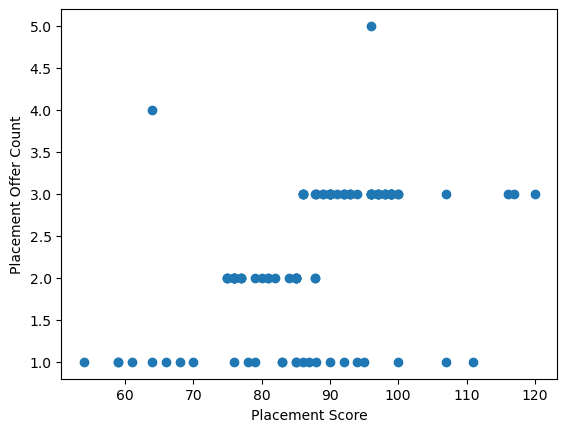

In [25]:
plt.scatter(df['Placement_Score'], df['Placement_Offer_Count'])
plt.xlabel("Placement Score")
plt.ylabel("Placement Offer Count")
plt.show()

In [34]:
median = np.median(sorted_rscore)
df['Reading_Score'] = np.where(df['Reading_Score'] > upper,median,df['Reading_Score'])
df['Reading_Score'] = np.where(df['Reading_Score'] < lower,median,df['Reading_Score'])
df


,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count
0,64,85.0,70.0,88.000000,2020.0,3
1,68,94.0,62.0,79.000000,2020.0,2
2,72,88.0,77.0,90.000000,2018.0,3
3,77,80.0,63.0,99.000000,2020.0,3
4,80,93.0,60.0,96.000000,2020.0,3
...,...,...,...,...,...,...
95,61,84.0,69.0,68.000000,NaN,1
96,72,75.0,86.0,87.804124,2020.0,2
97,95,85.0,80.0,61.000000,2021.0,1
98,69,88.0,55.0,99.000000,NaN,3


In [35]:
Q1 = df['Reading_Score'].quantile(0.25)
Q3 = df['Reading_Score'].quantile(0.75)
IQR = Q3- Q1
lower = Q1- 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [37]:
df.loc[df['Placement_Score'] < 75, 'Placement_Offer_Count'] = 1
df.loc[(df['Placement_Score'] >= 75) & (df['Placement_Score'] <= 85),'Placement_Offer_Count']
df.loc[df['Placement_Score'] > 85, 'Placement_Offer_Count'] = 3

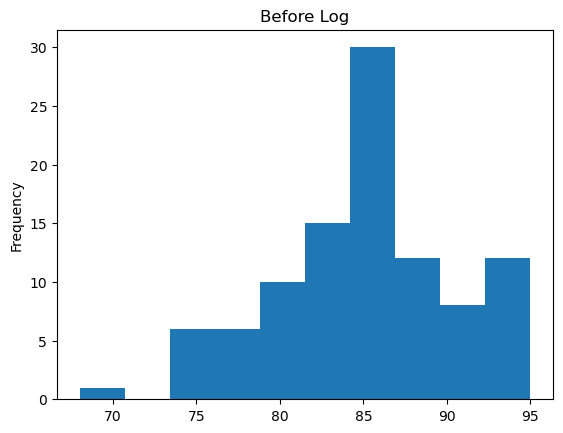

In [38]:
df['Reading_Score'].plot(kind='hist')
plt.title("Before Log")
plt.show()


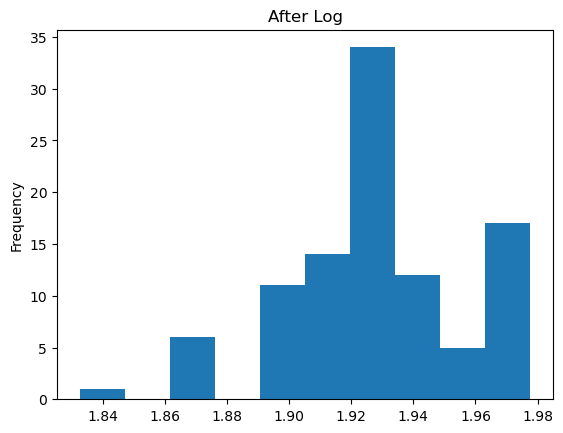

In [39]:
df['log_reading'] = np.log10(df['Reading_Score'])
df['log_reading'].plot(kind='hist')
plt.title("After Log")
plt.show()
